In [ ]:
#23 feb
# mask input tokens for loss
# stablity theory

#24 feb
#implemented mask for source tokens at loss, continue with training
# study bit more about stablity, warm up schedule
# any toy experiment that could reveal how warmup works..

In [ ]:
pip install fvcore

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=7b13e6739a8ff5619188d16cdb17c402aa17a163978e70a8b4a72e0c8c68cb8f
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a16a
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=c4f621f86e9d6f9a340042948225b7af9f215e70537e55128a3e49797977897e
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built fvcore iopath


In [ ]:
import pandas as pd
from tqdm import tqdm
import os

In [ ]:
train_df = pd.read_parquet("/content/train-00000-of-00001-ffdf7b19e4bcc0a0.parquet", engine="pyarrow")
test_df = pd.read_parquet("/content/test-00000-of-00001-e4b57af9a1be889a.parquet")

In [ ]:
# train_df = train_df.iloc[:10]
# test_df = test_df.iloc[:10]

In [ ]:

def iter_text(df, langs=("de", "en")):
    for item in df["translation"]:
        for lang in langs:
            yield item[lang]


In [ ]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

tokenizer = Tokenizer(BPE(unk_token="<unk>"))
tokenizer.pre_tokenizer = Whitespace()

trainer = BpeTrainer(
    vocab_size=32_000,
    min_frequency=2,
    special_tokens=["<pad>", "<unk>", "<bos>", "<eos>","<sep>"]
)

tokenizer.train_from_iterator(
    iter_text(train_df),
    trainer=trainer
)

tokenizer.save("bpe_tokenizer.json")


In [ ]:
lengths_en = []
lengths_de = []

for item in train_df["translation"]:
    en = item["en"]
    de = item["de"]

    en_len = len(tokenizer.encode(en))
    de_len = len(tokenizer.encode(de))

    lengths_en.append(en_len)
    lengths_de.append(de_len)


In [ ]:
from tokenizers import Tokenizer
import torch
import torch.nn.functional as F


class DecoderOnlyTranslationDataset(torch.utils.data.Dataset):
    def __init__(self, train_df, test_df, tokenizer_path, CUDA=False, max_len=64):
        super().__init__()

        # -------------------------
        # Load tokenizer
        # -------------------------
        self.tokenizer = Tokenizer.from_file(tokenizer_path)

        self.pad_id = self.tokenizer.token_to_id("<pad>")
        self.unk_id = self.tokenizer.token_to_id("<unk>")
        self.bos_id = self.tokenizer.token_to_id("<bos>")
        self.eos_id = self.tokenizer.token_to_id("<eos>")
        self.sep_id = self.tokenizer.token_to_id("<sep>")

        # If <sep> doesn't exist, fallback to eos
        if self.sep_id is None:
            self.sep_id = self.eos_id

        assert None not in [self.pad_id, self.unk_id, self.bos_id, self.eos_id]

        self.vocab_len = self.tokenizer.get_vocab_size()

        self.train_df = train_df.reset_index(drop=True)
        self.test_df = test_df.reset_index(drop=True)

        self.mode = "train"
        self.max_len = max_len

        self.device = torch.device("cuda:0" if CUDA else "cpu")

        print("pad_id:", self.pad_id)
        print("bos_id:", self.bos_id)
        print("eos_id:", self.eos_id)
        print("sep_id:", self.sep_id)

    # --------------------------------------------------

    def train(self):
        self.mode = "train"

    def test(self):
        self.mode = "test"

    # --------------------------------------------------

    def _encode(self, text):
        return torch.tensor(
            self.tokenizer.encode(text).ids,
            dtype=torch.long
        )

    # --------------------------------------------------

    def __getitem__(self, idx):

      row = (
          self.test_df.iloc[idx]
          if self.mode == "test"
          else self.train_df.iloc[idx]
      )

      en = self._encode(row["translation"]["en"])
      de = self._encode(row["translation"]["de"])

      # --------------------------------------------------
      # We need space for:
      # <bos> + en + <sep> + de + <eos>
      # Special tokens = 3
      # --------------------------------------------------
      special_tokens = 3
      max_content_len = self.max_len - special_tokens

      # --------------------------------------------------
      # If source alone is too long → truncate source
      # (rare but must be handled)
      # --------------------------------------------------
      if len(en) >= max_content_len:
          en = en[:max_content_len]
          de = torch.tensor([], dtype=torch.long)
      else:
          # Truncate ONLY target if needed
          max_de_len = max_content_len - len(en)
          de = de[:max_de_len]

      # --------------------------------------------------
      # Build final sequence
      # --------------------------------------------------
      seq = torch.cat([
          torch.tensor([self.bos_id]),
          en,
          torch.tensor([self.sep_id]),
          de,
          torch.tensor([self.eos_id])
      ])

      # --------------------------------------------------
      # Padding
      # --------------------------------------------------
      if len(seq) < self.max_len:
          seq = F.pad(seq, (0, self.max_len - len(seq)), value=self.pad_id)

      # --------------------------------------------------
      # Attention mask (1 = real token, 0 = pad)
      # --------------------------------------------------
      attention_mask = (seq != self.pad_id).long()

      return {
          "input_ids": seq.to(self.device),
          "attention_mask": attention_mask.to(self.device)
      }

    # --------------------------------------------------

    def __len__(self):
        return len(self.test_df) if self.mode == "test" else len(self.train_df)

In [ ]:
import torch

In [ ]:
from torch import nn
import torch.nn.functional as F

In [ ]:
relu = nn.ReLU()

In [ ]:
def scaled_dot_product(q, k, v, mask=False, dropout=None, pad_mask_in=None, pc="self_attn"):
    """
    Args:
        q: [batch, heads, seq_q, head_dim]
        k: [batch, heads, seq_k, head_dim]
        v: [batch, heads, seq_k, head_dim]
        mask: bool, if True apply causal masking (for decoder self-attention)
        pad_mask_in: [batch, seq] - True where padding is
        pc: "self_attn" or "cross_attn" (for debugging)
    """

    head_dim = q.shape[-1]
    scaled_attention = q @ k.transpose(-2, -1)  # [batch, heads, seq_q, seq_k]
    scaled_attention = scaled_attention / (head_dim ** 0.5)
    final_mask = None

    if mask:
        seq_q, seq_k = scaled_attention.shape[-2], scaled_attention.shape[-1]
        causal_mask = torch.triu(
            torch.ones(seq_q, seq_k, device=scaled_attention.device),
            diagonal=1
        ).bool()  # [seq_q, seq_k] - True where future is
        causal_mask = causal_mask[None, None, :, :]  # [1, 1, seq_q, seq_k]
        final_mask = causal_mask

    if pad_mask_in is not None:
        # pad_mask_in: [batch, seq_k] - True where padding is
        # We need: [batch, 1, 1, seq_k] to broadcast over heads and queries
        padding_mask = pad_mask_in[:, None, None, :]  # [batch, 1, 1, seq_k]

        if final_mask is None:
            final_mask = padding_mask
        else:
            # Combine causal and padding masks
            final_mask = final_mask | padding_mask
    # Apply mask
    if final_mask is not None:

        # Verify shapes match
        assert final_mask.shape[-1:] == scaled_attention.shape[-1:], \
            f"Mask shape {final_mask.shape} doesn't match attention {scaled_attention.shape}"
        # print("final_mask", final_mask)
        scaled_attention = scaled_attention.masked_fill(final_mask, float("-inf"))

        # Check if any row is completely masked

        if torch.isinf(scaled_attention).all(dim=-1).any():
            print(f"WARNING [{pc}]: Some queries have all keys masked!")
            # Replace -inf rows with zeros before softmax to avoid NaN
            all_masked = torch.isinf(scaled_attention).all(dim=-1, keepdim=True)
            scaled_attention = torch.where(all_masked, torch.zeros_like(scaled_attention), scaled_attention)

    # Softmax
    scaled_attention = F.softmax(scaled_attention, dim=-1)

    # Verify attention weights sum to 1
    attn_sums = scaled_attention.sum(dim=-1)
    if not torch.allclose(attn_sums, torch.ones_like(attn_sums), atol=1e-5):
        print(f"WARNING [{pc}]: Attention weights don't sum to 1! Range: [{attn_sums.min():.4f}, {attn_sums.max():.4f}]")

    # if dropout is not None:
    #     scaled_attention = dropout(scaled_attention)

    output = scaled_attention @ v

    return output, scaled_attention

In [ ]:

class Embedding(nn.Module):
    def __init__(self, embed_dim, vocab, max_seq_len=512,cuda=True):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings=vocab, embedding_dim=embed_dim)
        self.position_embedding = nn.Embedding(num_embeddings=max_seq_len, embedding_dim=embed_dim)
        self.embed_dim = embed_dim

    def forward(self, x):
        batch_size, seq_len = x.shape
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(batch_size, seq_len)
        x = self.embedding(x) + self.position_embedding(positions)
        return x


In [ ]:
def prepare_qkv(input, batch_size, seq_len, num_heads, head_dim, projection):

  out = projection(input)

  out = out.reshape(batch_size, seq_len, num_heads, head_dim)
  out = out.permute(0,2,1,3)
  return out


In [ ]:
class MultiHeadAttention(nn.Module):
  def __init__(self, embed_dim,num_heads,cuda=False):
#     self.encoder = nn.LSTM(
#     input_size=embed_dim,
#     hidden_size=hidden_dim,
#     batch_first=True
# )
#     self.decoder = nn.LSTM(input_size = output_dim,
#                            hidden_size = hidden_dim,
#                            batch_first=True)
    # print("vocab", vocab)
    super().__init__()
    # assert embed_dim%num_heads==0

    self.q_projection = nn.Linear(embed_dim, embed_dim)
    self.k_projection = nn.Linear(embed_dim, embed_dim)
    self.v_projection = nn.Linear(embed_dim, embed_dim)
    self.out_projection = nn.Linear(embed_dim, embed_dim)
    self.norm = nn.LayerNorm(embed_dim)
    self.dropout = nn.Dropout(0.1)
    self.num_heads = num_heads
    self.head_dim = embed_dim//num_heads
    assert embed_dim%num_heads == 0
    # self.device = torch.device("cuda:0" if cuda else "cpu")


  def forward(self, q_in, k_in, v_in, pad_mask, mask=False, pc="self_attn"):

    # 🔥 PRE-NORM (THIS IS THE FIX)
    q_norm = q_in
    k_norm = k_in
    v_norm = v_in
    batch_size, seq_len = q_norm.shape[0], q_norm.shape[1]
    k_batch_size, k_seq_len = k_norm.shape[0], k_norm.shape[1]

    Q = prepare_qkv(q_norm, batch_size, seq_len,
                    self.num_heads, self.head_dim, self.q_projection)

    K = prepare_qkv(k_norm, k_batch_size, k_seq_len,
                    self.num_heads, self.head_dim, self.k_projection)

    V = prepare_qkv(v_norm, k_batch_size, k_seq_len,
                    self.num_heads, self.head_dim, self.v_projection)

    attended_value, attention = scaled_dot_product(
        Q, K, V,
        mask=mask,
        dropout=self.dropout,
        pad_mask_in=pad_mask,
        pc=pc
    )

    attended_value = attended_value.permute(0,2,1,3)
    attended_value = attended_value.reshape(batch_size, seq_len, embed_dim)

    out = self.out_projection(attended_value)

    # residual WITHOUT norm now
    return out

    # self.attn_Q = nn.Lin

In [ ]:
class PositionalFeedForward(nn.Module):
    def __init__(self, embed_dim, hidden_dim=None, dropout=0.1):
        super().__init__()

        if hidden_dim is None:
            hidden_dim = 4 * embed_dim   # standard transformer width

        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, embed_dim)
        self.activation = nn.GELU()   # better than ReLU for transformers

    def forward(self, x):
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)

        return x


In [ ]:
class DecoderBlock(nn.Module):
    def __init__(self, embed_dim,num_heads, cuda=False):
        super().__init__()
        # Every block now has its OWN private weights for BOTH types of attention
        self.self_attn = MultiHeadAttention(embed_dim,num_heads, cuda=cuda)
        self.ff = PositionalFeedForward(embed_dim, embed_dim)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2= nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(0.1)
    def forward(self, x, pad_mask, causal=False):
    # 1. Self-attention (decoder attends to itself)
      residual = x
      x = self.norm1(x)
      x = self.self_attn(
          x, x, x,
          pad_mask=pad_mask,
          mask=causal
      )
      x = self.dropout(x) + residual

      # 2. Cross-attention (decoder attends to encoder) not needed because of encoder only architecture

      # 3. Feed-forward network
      residual = x
      x = self.norm2(x)
      x = self.ff(x)
      x = self.dropout(x) + residual

      return x

In [ ]:
class Decoder(nn.Module):
  def __init__(self, embed_dim, vocab, num_blocks,num_heads,cuda=False):
    super().__init__()
    self.blocks = nn.ModuleList([
            DecoderBlock(embed_dim,num_heads, cuda=cuda) for _ in range(num_blocks)
        ])
    self.fc = nn.Linear(embed_dim, vocab) # we can also say this converting back to logits??
    self.device = torch.device("cuda:0" if CUDA else "cpu")
  def forward(self,x,mask=False,pad_mask=None):
    for block in self.blocks:
      x = block(x,pad_mask,mask) # we have to include last dim alone in query?? to support auto regressive generation but not in training , we have to use mask
      # x = block(attention_outs, encoder_outs, encoder_outs, attention_outs,pad_mask_in=pad_mask_in)
    x = self.fc(x)
    return x


In [ ]:

class TransformerTranslator(nn.Module):
    def __init__(
        self,
        embed_dim,
        num_blocks,
        num_heads,
        vocab_size,
        CUDA=False,
    ):
        super().__init__()

        self.embedding = Embedding(embed_dim,vocab_size,cuda=CUDA)
        self.decoder = Decoder(
            embed_dim, vocab_size,num_blocks,num_heads, cuda=CUDA
        )
        # self.output_embedding.weight = self.decoder.fc.weight # Corrected: 'weights' to 'weight'
        self.decoder.fc.weight = self.embedding.embedding.weight


        self.device = torch.device("cuda:0" if CUDA else "cpu")

    def forward(self, input_sequence, mask=False):
        PAD_ID = 0
        pad_mask= (input_sequence == PAD_ID)
        embedding = self.embedding(input_sequence)
        return self.decoder(embedding, mask=mask,pad_mask=pad_mask)

In [ ]:
def load_training_state(checkpoint_path, model, optimizer, device="cuda"):
    """
    Loads model + optimizer + training metadata.
    Returns:
        num_steps, train_losses, val_losses
    """

    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"No checkpoint found at {checkpoint_path}")

    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint["model"])
    optimizer.load_state_dict(checkpoint["optimizer"])

    num_steps = checkpoint.get("epoch", 0)
    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])

    print(f"✅ Loaded checkpoint from {checkpoint_path}")
    print(f"Resuming from step {num_steps}")

    return num_steps, train_losses, val_losses

In [ ]:
from torch.utils.data import DataLoader
device = "cuda:0"
CUDA = True
dataset = DecoderOnlyTranslationDataset(train_df, test_df,"/content/bpe_tokenizer.json", CUDA=CUDA,max_len=64)
batch_size = 64
loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

pad_id: 0
bos_id: 2
eos_id: 3
sep_id: 4


In [ ]:

alpha = 2e-4
num_heads = 8      # Standard
num_blocks = 12      # Standard (like original Transformer)
hidden_dim = 256       # More capacity
embed_dim = hidden_dim  # 256
head_dim = embed_dim // num_heads  # 32
num_epochs = 5
vocab_size = dataset.vocab_len

In [ ]:
import math
# print("outpt", output_vocab_size)
model =TransformerTranslator(embed_dim,num_blocks,num_heads,vocab_size,CUDA=CUDA)
model=model.to(device)
# model = torch.compile(model) # Added torch.compile
model.train()
optimizer = torch.optim.Adam(model.parameters(), lr=0)
criterion = nn.CrossEntropyLoss(ignore_index=dataset.pad_id)
losses = []
val_losses = []
epoches = 0
# checkpoint = torch.load(
#     "/content/Checkpoint_epoch25 (4).pt",
#     map_location=device,
#     weights_only=False
# )
# model.load_state_dict(checkpoint["model"])

# train_losses = checkpoint["train_losses"]
# val_losses   = checkpoint["val_losses"]
# grad_norms   = checkpoint.get("grad_norms", [])

# epoch        = checkpoint.get("epoch", 0)
# _, losses_1, val_losses = load_training_state("/content/Checkpoint_epoch25 (2).pt",model, optimizer)
# scaler = torch.cuda.amp.GradScaler() # Initialize GradScaler for mixed precision

#why label smoothing is overkill linfor small models>
global_step = 0
warmup_steps = 1000
base_lr = 2e-4
total_steps = 50000  # set this to your actual total training steps
base_lr = 2e-4
min_lr = 2e-5

def get_lr(step):
    # Phase 1: Linear warmup
    if step <= warmup_steps:
        return base_lr * step / warmup_steps

    # Phase 2: Cosine decay
    progress = (step - warmup_steps) / (total_steps - warmup_steps)  # 0 → 1
    cosine = 0.5 * (1 + math.cos(math.pi * progress))
    return min_lr + (base_lr - min_lr) * cosine

def train(batch):
    model.train()
    optimizer.zero_grad()

    input_ids = batch["input_ids"]  # (B, T)

    decoder_in = input_ids[:, :-1]
    target     = input_ids[:, 1:]

    logits = model(decoder_in, mask=True)
    logits = logits.reshape(-1, vocab_size)

    sep_id = tokenizer.token_to_id("<sep>")
    pad_id = dataset.pad_id

    # Vectorized loss mask
    sep_mask = (input_ids == sep_id)
    sep_index = sep_mask.float().argmax(dim=1)

    positions = torch.arange(target.size(1), device=target.device).unsqueeze(0)
    loss_mask = positions >= sep_index.unsqueeze(1)

    loss_mask = loss_mask.reshape(-1)
    y = target.reshape(-1)

    y[~loss_mask] = pad_id
    loss = criterion(logits, y)

    assert torch.isfinite(loss), f"Loss is NaN: {loss}"

    loss.backward()
    block_norms = []

    for i, block in enumerate(model.decoder.blocks):
        total = 0.0
        for p in block.parameters():
            if p.grad is not None:
                total += p.grad.data.norm(2).item() ** 2
        block_norms.append(total ** 0.5)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    global num_steps
    num_steps += 1

    if num_steps <= warmup_steps:
        lr = base_lr * num_steps / warmup_steps
    else:
        lr = base_lr

    for param_group in optimizer.param_groups:
        param_group["lr"] = lr

    return loss.item(), block_norms

In [ ]:
def validate(loader):
    model.eval()
    running_val_loss = []

    sep_id = tokenizer.token_to_id("<sep>")
    pad_id = dataset.pad_id

    with torch.no_grad():
        for batch in loader:

            input_ids = batch["input_ids"]

            decoder_in = input_ids[:, :-1]
            target     = input_ids[:, 1:]

            logits = model(decoder_in, mask=True)
            logits = logits.reshape(-1, vocab_size)

            # --- Same masking logic as training ---
            sep_mask = (input_ids == sep_id)
            sep_index = sep_mask.float().argmax(dim=1)

            positions = torch.arange(
                target.size(1),
                device=target.device
            ).unsqueeze(0)

            loss_mask = positions >= sep_index.unsqueeze(1)
            loss_mask = loss_mask.reshape(-1)

            y = target.reshape(-1).clone()
            y[~loss_mask] = pad_id

            loss = criterion(logits, y)

            running_val_loss.append(loss.item())

    return sum(running_val_loss) / len(running_val_loss)

In [ ]:
SAVE_INTERVAL = 5000

In [ ]:
import os

CHECKPOINT_DIR = "/content/Checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


In [ ]:
from fvcore.nn import FlopCountAnalysis

dummy = torch.randint(0, vocab_size, (1, 64)).cuda()
flops_per_forward = FlopCountAnalysis(model, dummy).total()

# backward ≈ 2x forward (rough rule)
flops_per_step = flops_per_forward * 3

decoder.blocks.0.self_attn.dropout, decoder.blocks.0.self_attn.norm, decoder.blocks.1.self_attn.dropout, decoder.blocks.1.self_attn.norm, decoder.blocks.10.self_attn.dropout, decoder.blocks.10.self_attn.norm, decoder.blocks.11.self_attn.dropout, decoder.blocks.11.self_attn.norm, decoder.blocks.2.self_attn.dropout, decoder.blocks.2.self_attn.norm, decoder.blocks.3.self_attn.dropout, decoder.blocks.3.self_attn.norm, decoder.blocks.4.self_attn.dropout, decoder.blocks.4.self_attn.norm, decoder.blocks.5.self_attn.dropout, decoder.blocks.5.self_attn.norm, decoder.blocks.6.self_attn.dropout, decoder.blocks.6.self_attn.norm, decoder.blocks.7.self_attn.dropout, decoder.blocks.7.self_attn.norm, decoder.blocks.8.self_attn.dropout, decoder.blocks.8.self_attn.norm, decoder.blocks.9.self_attn.dropout, decoder.blocks.9.self_attn.norm


In [ ]:
import os
import time
import numpy as np
import torch
from tqdm import tqdm

all_epoch_block_norms = []
num_steps = 0

# -------------------------
# 🔥 One-time FLOPs setup
# -------------------------
# Make sure this matches your model input format
dummy = torch.randint(0, vocab_size, (1, 64)).cuda()

from fvcore.nn import FlopCountAnalysis
flops_per_forward = FlopCountAnalysis(model, dummy).total()
flops_per_step = flops_per_forward * 3  # forward + backward approx

# -------------------------
# TRAINING LOOP
# -------------------------
for epoch in tqdm(range(epoches, num_epochs)):

    # =========================
    # 🔥 Reset per-epoch stats
    # =========================
    torch.cuda.reset_peak_memory_stats()
    epoch_start_time = time.time()
    total_tokens = 0

    model.train()
    running_train_loss = []
    epoch_block_norms = []

    dataset.train()

    # =========================
    # TRAIN LOOP
    # =========================
    for batch in loader:

        loss, block_norms = train(batch)

        running_train_loss.append(loss)
        epoch_block_norms.append(block_norms)

        # ---- tokens tracking ----
        batch_size = batch["input_ids"].shape[0]
        seq_len = batch["input_ids"].shape[1]
        total_tokens += batch_size * seq_len

        num_steps += 1

        # ---- step checkpoint ----
        if num_steps % SAVE_INTERVAL == 0:
            os.makedirs("/content/Checkpoints", exist_ok=True)
            torch.save(
                {
                    "model": model.state_dict(),
                    "optimizer": optimizer.state_dict(),
                    "num_steps": num_steps,
                    "train_losses": losses,
                    "val_losses": val_losses,
                },
                f"/content/Checkpoints/Checkpoint_step{num_steps}.pt",
            )

    # =========================
    # 🔥 Block norm aggregation
    # =========================
    epoch_block_norms = np.array(epoch_block_norms)
    mean_block_norms = epoch_block_norms.mean(axis=0)
    all_epoch_block_norms.append(mean_block_norms)

    # =========================
    # LOSS
    # =========================
    avg_train_loss = sum(running_train_loss) / len(running_train_loss)
    losses.append(avg_train_loss)

    model.eval()
    dataset.test()
    avg_val_loss = validate(loader)
    val_losses.append(avg_val_loss)

    # =========================
    # 🔥 Compute stats
    # =========================
    epoch_time = time.time() - epoch_start_time
    gpu_mem_mb = torch.cuda.max_memory_allocated() / 1024**2
    tokens_per_sec = total_tokens / epoch_time
    total_flops = flops_per_step * len(loader)

    # =========================
    # PRINT LOG
    # =========================
    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"GPU Mem: {gpu_mem_mb:.2f} MB | "
        f"Throughput: {tokens_per_sec:.2f} tok/s"
    )

    # =========================
    # SAVE CHECKPOINT
    # =========================
    os.makedirs("/content/Checkpoints", exist_ok=True)
    torch.save(
        {
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "epoch": epoch,
            "train_losses": losses,
            "val_losses": val_losses,
            "grad_norms": all_epoch_block_norms,
            "gpu_mem_mb": gpu_mem_mb,
            "tokens_per_sec": tokens_per_sec,
            "flops_per_step": flops_per_step,
            "total_flops_epoch": total_flops,
        },
        f"/content/Checkpoints/Checkpoint_epoch{epoch+1}.pt",
    )

decoder.blocks.0.self_attn.dropout, decoder.blocks.0.self_attn.norm, decoder.blocks.1.self_attn.dropout, decoder.blocks.1.self_attn.norm, decoder.blocks.10.self_attn.dropout, decoder.blocks.10.self_attn.norm, decoder.blocks.11.self_attn.dropout, decoder.blocks.11.self_attn.norm, decoder.blocks.2.self_attn.dropout, decoder.blocks.2.self_attn.norm, decoder.blocks.3.self_attn.dropout, decoder.blocks.3.self_attn.norm, decoder.blocks.4.self_attn.dropout, decoder.blocks.4.self_attn.norm, decoder.blocks.5.self_attn.dropout, decoder.blocks.5.self_attn.norm, decoder.blocks.6.self_attn.dropout, decoder.blocks.6.self_attn.norm, decoder.blocks.7.self_attn.dropout, decoder.blocks.7.self_attn.norm, decoder.blocks.8.self_attn.dropout, decoder.blocks.8.self_attn.norm, decoder.blocks.9.self_attn.dropout, decoder.blocks.9.self_attn.norm
  0%|          | 0/5 [00:00<?, ?it/s]

Epoch [1/5] | Train Loss: 23.6899 | Val Loss: 5.9010 | GPU Mem: 2745.25 MB | Throughput: 23186.89 tok/s


 20%|██        | 1/5 [07:54<31:36, 474.22s/it]

Epoch [2/5] | Train Loss: 5.7558 | Val Loss: 5.1492 | GPU Mem: 2745.25 MB | Throughput: 22991.26 tok/s


 40%|████      | 2/5 [15:52<23:49, 476.64s/it]

...

 60%|██████    | 3/5 [23:52<15:56, 478.04s/it]

Epoch [4/5] | Train Loss: 4.7484 | Val Loss: 4.3052 | GPU Mem: 2745.25 MB | Throughput: 22835.89 tok/s


 80%|████████  | 4/5 [31:53<07:59, 479.42s/it]

Epoch [5/5] | Train Loss: 4.4282 | Val Loss: 4.0494 | GPU Mem: 2745.25 MB | Throughput: 22559.71 tok/s


100%|██████████| 5/5 [40:01<00:00, 480.24s/it]


In [ ]:

import os
import re

checkpoint_dir = "/content/Checkpoints"

def get_latest_checkpoint(path):
    files = os.listdir(path)

    pattern = r"Checkpoint_epoch(\d+)\.pt"
    epochs = []

    for f in files:
        match = re.match(pattern, f)
        if match:
            epochs.append((int(match.group(1)), f))

    if not epochs:
        return None

    latest_file = max(epochs, key=lambda x: x[0])[1]
    return os.path.join(path, latest_file)

latest_ckpt = get_latest_checkpoint(checkpoint_dir)
print("Latest checkpoint:", latest_ckpt)


Latest checkpoint: /content/Checkpoints/Checkpoint_epoch5.pt


In [ ]:
from google.colab import files

files.download(latest_ckpt)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_50_day_moving_losses(losses_list, labels=None, window=50):
    """
    losses_list: list of loss sequences (e.g., [losses_1, losses_2])
    labels: optional labels for each run
    """

    if labels is None:
        labels = [f"run_{i}" for i in range(len(losses_list))]

    for losses, label in zip(losses_list, labels):
        mod = losses
        # if not isinstance(losses[0], float):
        #     mod = [loss.to("cpu") for loss in losses]

        losses_np = np.array(mod)

        moving_avg = np.convolve(
            losses_np,
            np.ones(window) / window,
            mode="valid"
        )

        plt.plot(moving_avg, label=label)

    plt.title(f"{window} Moving Average Loss")
    plt.xlabel("Time")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

In [ ]:


def plot_50_day_moving_losses(losses, window=50):
  mod =losses
  if not isinstance(losses[0], float):
    mod = [loss.to("cpu") for loss in losses]
  # losses = losses.to("cpu")
  losses_np = np.array(mod)

  moving_avg = np.convolve(
      losses_np,
      np.ones(window) / window,
      mode="valid"
  )

  plt.plot(moving_avg)
  plt.title(f"{window}  Moving Average Loss")
  plt.xlabel("Time")
  plt.ylabel("Loss")


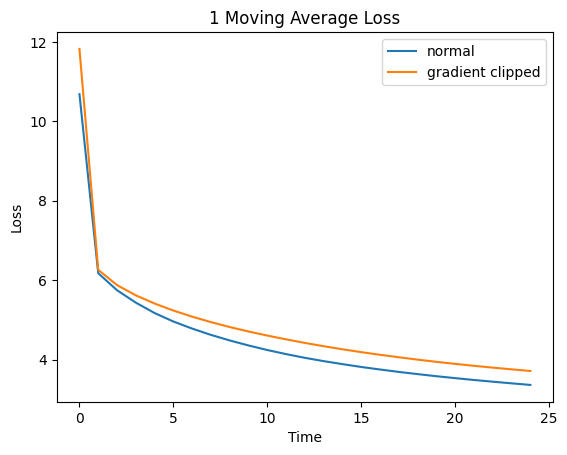

In [ ]:
plot_50_day_moving_losses([losses,losses_1],labels=["normal", "gradient clipped"], window=1)

In [ ]:
import torch
import torch.nn.functional as F

def translate_sentence_beam_decoder(
    model,
    sentence,
    tokenizer,
    beam_size=5,
    max_len=64,
    device="cuda"
):
    model.eval()

    bos_id = tokenizer.token_to_id("<bos>")
    eos_id = tokenizer.token_to_id("<eos>")
    sep_id = tokenizer.token_to_id("<sep>")

    # -------------------------
    # Build prompt
    # <bos> English <sep>
    # -------------------------
    en_ids = tokenizer.encode(sentence).ids
    prompt = [bos_id] + en_ids + [sep_id]

    # Each beam: (tokens, score)
    beams = [(prompt, 0.0)]

    with torch.no_grad():
        for _ in range(max_len):

            new_beams = []

            for tokens, score in beams:

                # If already ended, keep as is
                if tokens[-1] == eos_id:
                    new_beams.append((tokens, score))
                    continue

                input_ids = torch.tensor(tokens, device=device).unsqueeze(0)

                logits = model(input_ids, mask=True)
                next_logits = logits[:, -1, :]
                log_probs = F.log_softmax(next_logits, dim=-1)

                # Top-k candidates
                topk_log_probs, topk_ids = torch.topk(
                    log_probs, beam_size, dim=-1
                )

                for i in range(beam_size):
                    new_token = topk_ids[0, i].item()
                    new_score = score + topk_log_probs[0, i].item()
                    new_beams.append((tokens + [new_token], new_score))

            # Keep best k beams
            new_beams = sorted(
    new_beams,
    key=lambda x: x[1] / (len(x[0]) ** 0.7),
    reverse=True
)
            beams = new_beams[:beam_size]

            # Stop if all beams ended
            if all(b[0][-1] == eos_id for b in beams):
                break

    # Best sequence
    best_tokens = beams[0][0]

    # -------------------------
    # Extract German part
    # -------------------------
    if sep_id in best_tokens:
        sep_index = best_tokens.index(sep_id)
        best_tokens = best_tokens[sep_index + 1:]

    if eos_id in best_tokens:
        eos_index = best_tokens.index(eos_id)
        best_tokens = best_tokens[:eos_index]

    return tokenizer.decode(best_tokens)

In [ ]:
s = "could you take down the tree?"

In [ ]:
translate_sentence_beam_decoder(model, s, tokenizer)

'könnten Sie den Baum runter nehmen ?'

In [ ]:
import torch
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from tqdm import tqdm

def evaluate_bleu_decoder(
    model,
    val_data,
    tokenizer,
    beam_size=5,
    max_len=64,
    device="cuda",
    subset_size=None
):
    """
    val_data: list of (source_sentence, target_sentence)
    subset_size: evaluate only first N samples (for fast dev)
    """

    model.eval()

    references = []
    hypotheses = []

    if subset_size is not None:
        val_data = val_data[:subset_size]

    with torch.no_grad():
        for src_sentence, tgt_sentence in tqdm(val_data):
            # print("src:", src_sentence)
            # print("tgt:", tgt_sentence)
            pred = translate_sentence_beam_decoder(
                model,
                src_sentence,
                tokenizer,
                beam_size=beam_size,
                max_len=max_len,
                device=device
            )
            # print("pred:", pred)
            # Tokenize by whitespace for BLEU
            references.append([tgt_sentence.split()])
            hypotheses.append(pred.split())

    smoothie = SmoothingFunction().method4
    bleu = corpus_bleu(
        references,
        hypotheses,
        smoothing_function=smoothie
    )

    return bleu * 100

In [ ]:
subset_df = test_df
val_data = [
    (row['translation']['en'], row['translation']['de'])
    for _, row in subset_df.iterrows()
]

In [ ]:
bleu_small = evaluate_bleu_decoder(
    model,
    val_data,
    tokenizer,
    beam_size=5,      # greedy
    subset_size=200   # fast check
)

print("BLEU (subset):", bleu_small)

100%|██████████| 200/200 [02:35<00:00,  1.29it/s]

BLEU (subset): 7.107139148647885


In [ ]:
#200 subset
#epoch 25 - 6.73
#epoch 35 - 7.10
#

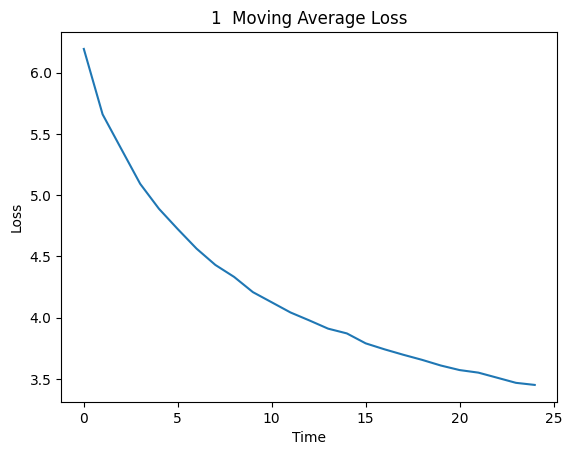

In [ ]:
plot_50_day_moving_losses(val_losses[:], window=1)

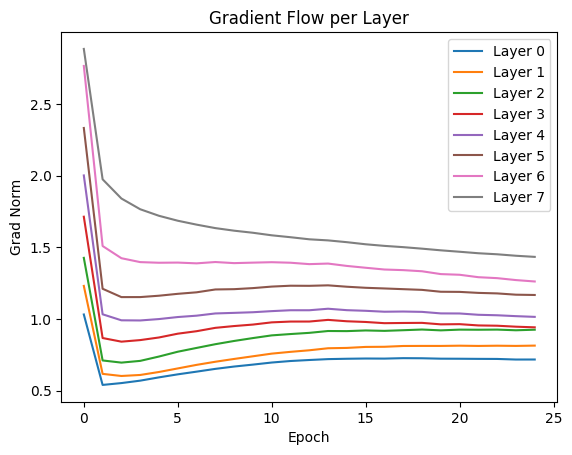

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

norms = np.array(grad_norms)

for i in range(norms.shape[1]):
    plt.plot(norms[:, i], label=f"Layer {i}")

plt.xlabel("Epoch")
plt.ylabel("Grad Norm")
plt.title("Gradient Flow per Layer")
plt.legend()
plt.show()